Number of people (nodes): 4
Number of connections (edges): 4
Alice has 2 connections
Bob has 2 connections
Carol has 3 connections
Dave has 1 connections


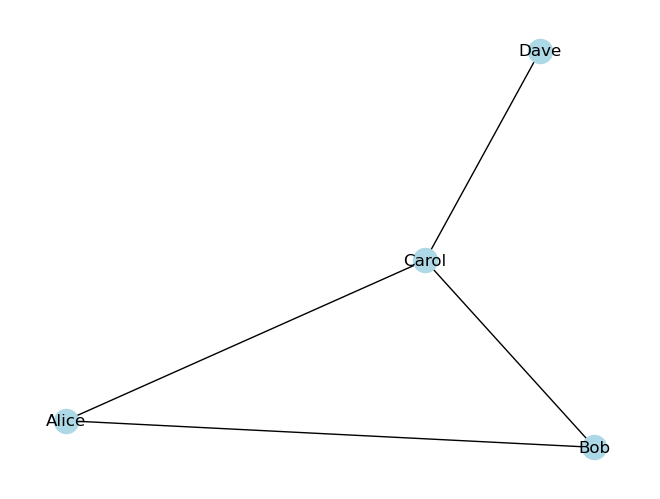

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a tiny graph by hand first, just to see the mechanics
G = nx.Graph()
G.add_edge("Alice", "Bob")
G.add_edge("Bob", "Carol")
G.add_edge("Carol", "Alice")
G.add_edge("Carol", "Dave")

print("Number of people (nodes):", G.number_of_nodes())
print("Number of connections (edges):", G.number_of_edges())

# Degree = how many connections each person has
for node in G.nodes():
    print(node, "has", G.degree(node), "connections")

# Visualize it
nx.draw(G, with_labels=True, node_color="lightblue")
plt.show()

In [3]:
# A Barabási-Albert graph mimics real social networks:
# most people have few connections, a small number are highly connected hubs
G_real = nx.barabasi_albert_graph(n=200, m=3)  # 200 nodes, each new node connects to 3 existing ones

print("Nodes:", G_real.number_of_nodes())
print("Edges:", G_real.number_of_edges())

# Get the degree of every node, sorted, to see the hub structure
degrees = dict(G_real.degree())
top_5_hubs = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 most-connected nodes:", top_5_hubs)

Nodes: 200
Edges: 591
Top 5 most-connected nodes: [(0, 41), (6, 41), (3, 32), (4, 30), (5, 24)]


In [4]:
degree_centrality = nx.degree_centrality(G_real)
betweenness_centrality = nx.betweenness_centrality(G_real)

# Compare top nodes by each measure
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top by degree centrality:", top_degree)
print("Top by betweenness centrality:", top_betweenness)

Top by degree centrality: [(0, 0.20603015075376885), (6, 0.20603015075376885), (3, 0.16080402010050251), (4, 0.15075376884422112), (5, 0.12060301507537688)]
Top by betweenness centrality: [(6, 0.20338151882769034), (0, 0.1888869871234846), (3, 0.1265460323130223), (4, 0.1198073079440023), (5, 0.08083475168403707)]


In [5]:
import numpy as np

adjacency_matrix = nx.to_numpy_array(G_real)
eigenvalues = np.linalg.eigvals(adjacency_matrix)
spectral_radius = max(eigenvalues.real)
print("Spectral radius:", spectral_radius)

# The theoretical epidemic threshold for SIR on this network is roughly:
gamma = 1.0  # arbitrary recovery rate for now
theoretical_threshold_beta = gamma / spectral_radius
print("Approximate epidemic threshold (beta):", theoretical_threshold_beta)

Spectral radius: 10.45178982212923
Approximate epidemic threshold (beta): 0.09567739277369823


In [1]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

text = "If we don't stop them now, they will destroy everything we love."
candidate_labels = ["appeal to fear", "false dichotomy", "loaded language", "neutral statement"]

result = classifier(text, candidate_labels)
print(result)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

{'sequence': "If we don't stop them now, they will destroy everything we love.", 'labels': ['appeal to fear', 'loaded language', 'false dichotomy', 'neutral statement'], 'scores': [0.6393217444419861, 0.19008740782737732, 0.13032390177249908, 0.04026699811220169]}
